# 02a Preprocessing — Exclusion Masks

**PA1 ZHAW IUNR** | Bächler, Haag, Reichlin | Supervisor: Patrick Laube

Creates 20 boolean exclusion masks for scenario S2 (medium) and
combines them into a single constraint mask.

**Methodology:** All vector datasets (protected areas, land cover, water bodies,
natural hazard points, settlements) are rasterized to a uniform **25 m grid**
(EPSG:2056). Only this way can the 20 individual masks be pixelwise
multiplied together: `constraint_mask = C01 × C02 × … × C20`.

**Input:**

**Input:**
```
data/raw/dem/                       DEM (DHM25)
data/raw/permafrost/                Permafrost indicator map
data/raw/tlm3d/                     swissTLM3D
data/raw/hazards/                   Natural hazard inventory GR
data/raw/protected_areas/           Protected areas (BAFU)
data/raw/swissboundaries/           Canton border GR
```

**Output:**
```
data/processed/constraints/         constraint_mask_s2.tif (0 = excluded, 1 = suitable)
data/processed/dem/                 dem_gr_25m.tif (DEM at 25 m)
data/processed/dem/                 slope_gr_25m.tif (Slope)
data/processed/dem/                 aspect_gr_25m.tif (Aspect)
```


**Scenario S2 Thresholds:**
| Parameter | Value | Source |
|-----------|-------|--------|
| Elevation | 1500–2700 m | Dujardin et al. (2022) |
| Slope | < 35° | Swissolar (2025) |
| Aspect | 120°–240° | Kahl et al. (2019) |
| Building buffer | 100 m | De Ferrars (2023) |
| Permafrost | Exclude > Class 3 | Swissolar (2025) |
| Minimum area | ≥ 10 ha | Swissolar (2025) |

## 1. Setup & Imports

In [1]:
# Import required libraries
from pathlib import Path                                                   # Cross-platform file path handling
import geopandas as gpd                                                    # Geospatial data manipulation (shapefiles, GeoJSON)
import numpy as np                                                         # Numerical computing
import pandas as pd                                                        # Tabular data analysis
import rasterio                                                            # Read/write raster data (GeoTIFF, etc.)
from rasterio.enums import Resampling                                      # Resampling methods for raster reprojection
from rasterio.mask import mask as rio_mask                                 # Clip raster data with vector geometries
from rasterio.transform import from_bounds                                 # Create georeferencing transform from bounds
from rasterio.features import rasterize                                    # Convert vector geometries to raster
from rasterio.warp import reproject                                        # Reproject raster to target CRS/grid
import matplotlib.pyplot as plt                                            # Data visualization
from matplotlib.colors import LinearSegmentedColormap                      # Create custom colormaps for visualization
from matplotlib.patches import Patch                                       # Legend patch objects
from scipy.ndimage import binary_dilation                                  # Morphological dilation for buffering
from shapely.geometry import Point                                         # Point geometry for hazard locations
import warnings
warnings.filterwarnings("ignore")                                          # Suppress non-critical warnings for cleaner output

#Define data paths
RAW  = Path("../data/raw")                                                # Raw input data directory
PROC = Path("../data/processed")                                           # Processed data directory
for sub in ["dem", "constraints"]:
    (PROC / sub).mkdir(parents=True, exist_ok=True)                        # Create output subdirectories if missing

#Constants
CRS    = "EPSG:2056"                                                       # Target CRS (LV95, Swiss standard)
RES    = 25                                                                # Pixel resolution [m]
NODATA = -9999.0                                                           # NoData value for missing/invalid pixels

print("✓ Setup OK")

✓ Setup OK


## 2. Configuration — Scenario S2

In [2]:
# ╔══════════════════════════════════════════════════════════╗
# ║  ADJUST THRESHOLDS HERE  (Scenario S2 = medium)         ║
# ╚══════════════════════════════════════════════════════════╝

S2 = {
    "elevation_min": 1500,                                                 # Minimum elevation [m]
    "elevation_max": 2700,                                                 # Maximum elevation [m]
    "slope_max": 35,                                                       # Maximum slope gradient [°]
    "aspect_min": 120,                                                     # Minimum aspect angle [°]
    "aspect_max": 240,                                                     # Maximum aspect angle [°]
    "building_buffer": 300,                                                # Settlement distance [m]
    "permafrost_exclude_above": 3,                                         # Permafrost class threshold for exclusion
}

print(f"Scenario S2: {S2}")

Scenario S2: {'elevation_min': 1500, 'elevation_max': 2700, 'slope_max': 35, 'aspect_min': 120, 'aspect_max': 240, 'building_buffer': 300, 'permafrost_exclude_above': 3}


## 3. Functions

In [3]:
def get_tlm_path():
    """Returns path to swissTLM3D GeoPackage file."""
    tlm = RAW / "tlm3d/swisstlm3d_2026-02-24_2056_5728.gpkg"
    return next(tlm.glob("*.gpkg")) if tlm.is_dir() else tlm              # .gpkg may be a directory containing the actual file


def clip_raster_to_gr(src_path):
    """Clips and reprojects a raster to the GR reference grid."""
    with rasterio.open(src_path) as src:  # Open source raster file
        gr_clip = gr_border.to_crs(src.crs) if src.crs and src.crs != CRS else gr_border  # Reproject GR boundary if needed
        out, out_tf = rio_mask(src, [gr_clip.geometry.iloc[0].__geo_interface__], crop=True, nodata=src.nodata or NODATA)  # Clip to GR extent
    dst = np.full((height, width), NODATA, dtype=np.float32)               # Initialize destination raster array
    reproject(                                                             # Reproject to reference grid
        source=out[0], destination=dst,
        src_transform=out_tf, src_crs=src.crs,
        dst_transform=transform, dst_crs=CRS,
        resampling=Resampling.bilinear,
        src_nodata=src.nodata or NODATA, dst_nodata=NODATA
    )
    return dst


def rasterize_to_gr(gdf, burn=1):
    """Rasterizes vector data to the GR reference grid."""
    gdf_c = gdf.to_crs(CRS)                                               # Transform to target CRS
    minx, miny, maxx, maxy = gr_border.total_bounds                        # Get GR extent bounds [minx, miny, maxx, maxy]
    gdf_c = gdf_c.cx[minx:maxx, miny:maxy]                                # Clip to extent (spatial slicing)
    if gdf_c.empty:  # If no features remain after clipping
        return np.zeros((height, width), dtype=np.uint8)  # Return empty raster (all zeros)
    return rasterize(
        [(g, burn) for g in gdf_c.geometry if g is not None and not g.is_empty],  # Generate (geometry, value) tuples
        out_shape=(height, width), transform=transform, fill=0, dtype=np.uint8  # Rasterize with specified shape/transform
    )


def simplify_and_rasterize(gdf, tolerance=5, buffer=0):
    """Simplifies geometries and rasterizes to reference grid."""
    gdf = gdf.to_crs(CRS).copy()                                          # Transform CRS to target
    gdf.geometry = gdf.geometry.simplify(tolerance)                        # Simplify geometries (reduce vertices)
    if buffer > 0:  # If buffer distance specified
        gdf.geometry = gdf.geometry.buffer(buffer)                         # Apply buffer (expand boundaries)
    return rasterize_to_gr(gdf)  # Rasterize simplified/buffered geometries


def save_mask(data, name):
    """Saves a boolean mask as GeoTIFF (uint8, compressed)."""
    path = PROC / f"constraints/{name}.tif"  # Define output file path
    with rasterio.open(path, "w", **{**ref_profile, "dtype": "uint8", "nodata": 255}) as dst:  # Open for writing
        dst.write(data.astype(np.uint8), 1)  # Write data to band 1 (convert to uint8)


def report(name, mask, total_pixels):
    """Prints area statistics for a constraint mask."""
    valid = mask.sum()                                                     # Count suitable pixels (value = 1)
    excl = total_pixels - valid                                            # Count excluded pixels (value = 0)
    print(f"  {name:40s} {valid*RES*RES/1e6:>7.0f} km² ✓ | {excl*RES*RES/1e6:>7.0f} km² ✗ ({excl/total_pixels*100:.1f}%)")  # Print formatted statistics
    return mask


print("✓ Functions defined")

✓ Functions defined


## 4. Reference Raster & Canton Border GR

In [4]:
print("=== Reference Raster & Canton Border GR ===\n")

#Load municipality data
municipalities = gpd.read_file(RAW / "swissboundaries/swissboundaries_gemeinden.shp")  # Load Swiss municipalities
canton_col = next(c for c in municipalities.columns if "KANT" in c.upper() or c.upper().startswith("KT"))  # Identify canton code column

#Filter for Graubünden and dissolve
gr_muni = municipalities[municipalities[canton_col].astype(str).str.contains("GR", case=False, na=False)].copy()  # Filter by "GR" string
if gr_muni.empty:  # If no "GR" match found
    gr_muni = municipalities[municipalities[canton_col].astype("Int64") == 18].copy()  # Try numeric code 18 (Graubünden)
gr_border = gr_muni.dissolve()                                             # Merge all municipality geometries into single polygon
gr_geom = [gr_border.geometry.iloc[0].__geo_interface__]                   # Convert geometry to dict format

#Derive reference raster from GR bounds
bounds = gr_border.total_bounds                                            # Get extent: [minx, miny, maxx, maxy]
width = int(np.ceil((bounds[2] - bounds[0]) / RES))                        # Raster width [pixels]
height = int(np.ceil((bounds[3] - bounds[1]) / RES))                       # Raster height [pixels]
transform = from_bounds(bounds[0], bounds[1], bounds[0] + width * RES, bounds[1] + height * RES, width, height)  # Create transform
ref_profile = {  # Define GeoTIFF metadata profile
    "driver": "GTiff", "dtype": "float32", "crs": CRS, "transform": transform,
    "width": width, "height": height, "count": 1, "nodata": NODATA, "compress": "lz4"  # LZ4 compression for faster I/O
}

#Rasterize GR boundary
gr_mask_raster = rasterize(
    [(gr_border.geometry.iloc[0], 1)],  # (geometry, value) tuple
    out_shape=(height, width), transform=transform, fill=0, dtype=np.uint8  # Pixels within GR = 1, outside = 0
)
total_px = gr_mask_raster.sum()                                            # Total pixels within GR
px2km = RES * RES / 1e6                                                   # Conversion factor: pixels → km²

print(f"GR: {len(gr_muni)} municipalities | {width}×{height} pixels @ {RES}m | {total_px*px2km:.0f} km²")

=== Reference Raster & Canton Border GR ===

GR: 100 municipalities | 5641×4010 pixels @ 25m | 7105 km²


## 5.  Load DEM & Derivatives

In [5]:
print("=== Load DEM ===\n")

#Search for DEM file (.tif or .asc)
dem_path = next((RAW / "dem").glob("*.tif"), None)  # Search for GeoTIFF format first
if not dem_path:  # If no .tif found
    asc_search = list((RAW / "dem").glob("**/dhm25_grid_raster.asc"))  # Recursively search for ASCII grid format
    dem_path = asc_search[0] if asc_search else None  # Take first result if found
if not dem_path:  # If neither format found
    raise FileNotFoundError("No DEM found in data/raw/dem/")  # Raise error with message

#Clip DEM to GR reference grid
dem = clip_raster_to_gr(dem_path)  # Clip and reproject to reference grid
valid_dem = (dem != NODATA) & (gr_mask_raster == 1)                        # Valid pixels: non-nodata AND within GR

#Compute Slope & Aspect via finite-difference (Horn 1981)
dy, dx = np.gradient(np.where(valid_dem, dem, 0).astype(float), RES)       # Calculate elevation gradients [m/m]
slope = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2))).astype(np.float32)   # Slope in degrees: atan(gradient magnitude)
aspect = (np.degrees(np.arctan2(-dx, dy)) % 360).astype(np.float32)        # Aspect in degrees [0–360°]: direction of steepest slope

#Save DEM derivatives
for name, data in [("dem_gr_25m", dem), ("slope_gr_25m", slope), ("aspect_gr_25m", aspect)]:  # For each dataset
    with rasterio.open(PROC / f"dem/{name}.tif", "w", **ref_profile) as dst:  # Create output GeoTIFF
        dst.write(data, 1)  # Write data to band 1

print(f"  DEM: {dem[valid_dem].min():.0f}–{dem[valid_dem].max():.0f} m | Slope: {slope[valid_dem].mean():.1f}° mean")

=== Load DEM ===

  DEM: 255–4040 m | Slope: 27.3° mean


## 6. DEM-based Exclusions (C01–C05)

In [6]:
print("=== C01–C05: DEM-based Exclusions ===\n")

#Compute DEM-based masks
masks_dem = {
    "c01_elev_min": ("Elevation ≥ 1500 m", (dem >= S2["elevation_min"]) & valid_dem),  # C01: minimum elevation threshold
    "c02_elev_max": ("Elevation ≤ 2700 m", (dem <= S2["elevation_max"]) & valid_dem),  # C02: maximum elevation threshold
    "c03_slope":    ("Slope < 35°",    (slope < S2["slope_max"]) & valid_dem),  # C03: slope gradient limit
    "c04_aspect":   ("Aspect 120–240°", (aspect >= S2["aspect_min"]) & (aspect <= S2["aspect_max"]) & valid_dem),  # C04: N-facing slopes only
}

for cid, (label, condition) in masks_dem.items():  # For each criterion
    m = condition.astype(np.uint8)                                         # Convert boolean to uint8 (0/1)
    report(f"{cid.upper()} {label}", m, total_px)  # Print statistics
    save_mask(m, cid)  # Save to GeoTIFF
    globals()[cid] = m                                                     # Store in global scope for later use

#C05: Permafrost
pf_path = RAW / "permafrost/permafrost_2056.tif"  # Expected permafrost file path
if pf_path.exists():  # If permafrost file found
    pf = clip_raster_to_gr(pf_path)                                       # Load and clip to reference grid
    c05_permafrost = (valid_dem & ~((pf != NODATA) & (dem >= pf))).astype(np.uint8)  # Exclude: where DEM ≥ permafrost value
else:  # If permafrost file not found
    print("  ⚠ Permafrost not found")  # Print warning
    c05_permafrost = valid_dem.astype(np.uint8)                            # Fallback: no exclusion
report("C05 Permafrost", c05_permafrost, total_px)  # Print statistics
save_mask(c05_permafrost, "c05_permafrost")  # Save to GeoTIFF

=== C01–C05: DEM-based Exclusions ===

  C01_ELEV_MIN Elevation ≥ 1500 m             5739 km² ✓ |    1366 km² ✗ (19.2%)
  C02_ELEV_MAX Elevation ≤ 2700 m             6372 km² ✓ |     733 km² ✗ (10.3%)
  C03_SLOPE Slope < 35°                       5237 km² ✓ |    1868 km² ✗ (26.3%)
  C04_ASPECT Aspect 120–240°                  2308 km² ✓ |    4797 km² ✗ (67.5%)
  C05 Permafrost                              5963 km² ✓ |    1142 km² ✗ (16.1%)


## 7. Nature Conservation Exclusions (C06–C12)

In [7]:
print("=== C06–C12: Protected Areas (BAFU) ===\n")

# --- AULAV sublayer paths ---
aulav_base = RAW / "protected_areas/schutzgebiete-aulav_2056.shp"  # AULAV shapefile directory
uebrige_shp = aulav_base / "N2023_AulavUebrigeSchutzgebiete_20230701.shp"  # "Other protected areas" shapefile
uebrige = gpd.read_file(uebrige_shp) if uebrige_shp.exists() else None    # Load once, reuse for C08, C10

# --- C06: Peatland landscapes ---
moor_shp = aulav_base / "N2017_AulavMoorlandschaft_20171101.shp"  # Peatland shapefile
if moor_shp.exists():  # If file exists
    gdf = gpd.read_file(moor_shp)  # Load peatland polygons
    c06_moorlandschaften = ((rasterize_to_gr(gdf) == 0) & (gr_mask_raster == 1)).astype(np.uint8)  # Rasterize and exclude
else:  # If file missing
    print("  ⚠ C06 Peatland landscapes: not found")  # Print warning
    c06_moorlandschaften = np.ones((height, width), dtype=np.uint8)        # Fallback: no exclusion
report("C06 Peatland landscapes", c06_moorlandschaften, total_px)  # Print statistics
save_mask(c06_moorlandschaften, "c06_moorlandschaften")  # Save to GeoTIFF

# --- C07: Biotopes (floodplains + high/low peatlands) ---
auen_shp = aulav_base / "N2017_AulavAuen_20171101.shp"  # Floodplain shapefile
biotop_parts = []  # Initialize list for biotope GeoDataFrames
if auen_shp.exists():  # If floodplain file exists
    biotop_parts.append(gpd.read_file(auen_shp))                          # Add floodplains to list
if uebrige is not None:  # If "other protected areas" loaded
    biotop_parts.append(uebrige[uebrige["Discrimina"].isin(["Hochmoore", "Flachmoore"])])  # Add peatlands from AULAV
if biotop_parts:  # If any biotope data collected
    gdf_biotop = pd.concat(biotop_parts, ignore_index=True)               # Concatenate all biotope polygons
    c07_biotope = ((rasterize_to_gr(gdf_biotop) == 0) & (gr_mask_raster == 1)).astype(np.uint8)  # Rasterize and exclude
    report(f"C07 Biotopes ({len(gdf_biotop)} Features)", c07_biotope, total_px)  # Print with feature count
else:  # If no biotope data found
    print("  ⚠ C07 Biotopes: not found")  # Print warning
    c07_biotope = np.ones((height, width), dtype=np.uint8)  # Fallback: no exclusion
save_mask(c07_biotope, "c07_biotope")  # Save to GeoTIFF

# --- C08: Water & migratory bird reserves ---
if uebrige is not None:  # If "other protected areas" loaded
    gdf_vogel = uebrige[uebrige["Discrimina"] == "WildUndZugvogelReservat"]  # Filter for bird reserve category
    c08_vogelreservate = ((rasterize_to_gr(gdf_vogel) == 0) & (gr_mask_raster == 1)).astype(np.uint8)  # Rasterize and exclude
    report(f"C08 Bird reserves ({len(gdf_vogel)} Features)", c08_vogelreservate, total_px)  # Print with feature count
else:  # If "other protected areas" not found
    print("  ⚠ C08 Bird reserves: not found")  # Print warning
    c08_vogelreservate = np.ones((height, width), dtype=np.uint8)  # Fallback: no exclusion
save_mask(c08_vogelreservate, "c08_vogelreservate")  # Save to GeoTIFF

# --- C09: BLN (Federal Inventory of Landscapes) ---
bln_path = RAW / "protected_areas/bundesinventare-bln_2056.shp"  # BLN shapefile path
if bln_path.exists():  # If file exists
    gdf = gpd.read_file(bln_path)  # Load BLN polygons (federal heritage sites)
    c09_bln = ((rasterize_to_gr(gdf) == 0) & (gr_mask_raster == 1)).astype(np.uint8)  # Rasterize and exclude
    report(f"C09 BLN ({len(gdf)} Features)", c09_bln, total_px)  # Print with feature count
else:  # If file missing
    print("  ⚠ C09 BLN: not found")  # Print warning
    c09_bln = np.ones((height, width), dtype=np.uint8)  # Fallback: no exclusion
save_mask(c09_bln, "c09_bln")  # Save to GeoTIFF

# --- C10: National Park ---
if uebrige is not None:  # If "other protected areas" loaded
    gdf_np = uebrige[uebrige["Discrimina"] == "Nationalpark"]  # Filter for national park category
    c10_nationalpark = ((rasterize_to_gr(gdf_np) == 0) & (gr_mask_raster == 1)).astype(np.uint8)  # Rasterize and exclude
    report(f"C10 National Park ({len(gdf_np)} Features: {gdf_np['Name'].tolist()})", c10_nationalpark, total_px)  # Print with names
else:  # If "other protected areas" not found
    print("  ⚠ C10 National Park: not found")  # Print warning
    c10_nationalpark = np.ones((height, width), dtype=np.uint8)  # Fallback: no exclusion
save_mask(c10_nationalpark, "c10_nationalpark")  # Save to GeoTIFF

# --- C11: Biosphere Reserve ---
bio_path = RAW / "protected_areas/schutzgebiete-biosphaerenreservate_2056.shp"  # Biosphere reserve shapefile
if bio_path.exists():  # If file exists
    gdf = gpd.read_file(bio_path)  # Load biosphere reserve polygons
    c11_biosphaere = ((rasterize_to_gr(gdf) == 0) & (gr_mask_raster == 1)).astype(np.uint8)  # Rasterize and exclude
    report(f"C11 Biosphere Reserve ({len(gdf)} Features)", c11_biosphaere, total_px)  # Print with feature count
else:  # If file missing
    print("  ⚠ C11 Biosphere Reserve: not found")  # Print warning
    c11_biosphaere = np.ones((height, width), dtype=np.uint8)  # Fallback: no exclusion
save_mask(c11_biosphaere, "c11_biosphaere")  # Save to GeoTIFF

# --- C12: UNESCO World Heritage ---
unesco_path = RAW / "protected_areas/unesco-weltnaturerbe_2056.shp"  # UNESCO shapefile path
if unesco_path.exists():  # If file exists
    gdf = gpd.read_file(unesco_path)  # Load UNESCO World Heritage polygons
    c12_unesco = ((rasterize_to_gr(gdf) == 0) & (gr_mask_raster == 1)).astype(np.uint8)  # Rasterize and exclude
    report(f"C12 UNESCO ({len(gdf)} Features)", c12_unesco, total_px)  # Print with feature count
else:  # If file missing
    print("  ⚠ C12 UNESCO: not found")  # Print warning
    c12_unesco = np.ones((height, width), dtype=np.uint8)  # Fallback: no exclusion
save_mask(c12_unesco, "c12_unesco")  # Save to GeoTIFF

=== C06–C12: Protected Areas (BAFU) ===

  C06 Peatland landscapes                     7015 km² ✓ |      90 km² ✗ (1.3%)
  C07 Biotopes (2212 Features)                7016 km² ✓ |      90 km² ✗ (1.3%)
  C08 Bird reserves (35 Features)             7105 km² ✓ |       0 km² ✗ (0.0%)
  C09 BLN (174 Features)                      5821 km² ✓ |    1284 km² ✗ (18.1%)
  C10 National Park (1 Features: ['Schweizerischer Nationalpark'])    6935 km² ✓ |     170 km² ✗ (2.4%)
  C11 Biosphere Reserve (6 Features)          6657 km² ✓ |     449 km² ✗ (6.3%)
  C12 UNESCO (8 Features)                     7060 km² ✓ |      46 km² ✗ (0.6%)


## 8. Land Cover & Water Bodies (C13–C15)

In [8]:
print("=== C13–C15: Land Cover & Water Bodies (swissTLM3D) ===\n")

#Load TLM3D data
tlm_path = get_tlm_path()  # Get GeoPackage path
gr_bbox = tuple(gr_border.total_bounds)                                    # Bounding box: [minx, miny, maxx, maxy]
boden = gpd.read_file(str(tlm_path), layer="tlm_bb_bodenbedeckung", bbox=gr_bbox)  # Load land cover layer within bbox
fliess = gpd.read_file(str(tlm_path), layer="tlm_gewaesser_fliessgewaesser", bbox=gr_bbox)  # Load flowing water layer
stehend = gpd.read_file(str(tlm_path), layer="tlm_gewaesser_stehendes_gewaesser", bbox=gr_bbox)  # Load standing water layer

print(f"  Land cover: {len(boden)} Features | Water bodies: {len(fliess)} + {len(stehend)} Features\n")

#C13: Forest | C15: Glacier
for cid, label, pattern, tol in [
    ("c13_wald", "Forest", "Wald|wald", 5),  # C13: forest areas (pattern-match in objektart column)
    ("c15_gletscher", "Glacier", "Gletsch|Firn", 5),  # C15: glacier/firn areas
]:
    subset = boden[boden["objektart"].str.contains(pattern, case=False, na=False)]  # Filter by pattern (case-insensitive)
    mask = (simplify_and_rasterize(subset, tolerance=tol) == 0) & (gr_mask_raster == 1)  # Rasterize with 5m simplification tolerance
    mask = mask.astype(np.uint8) if len(subset) else gr_mask_raster.copy().astype(np.uint8)  # Convert to uint8; use gr_mask if empty
    report(f"{cid.upper()} {label}", mask, total_px)  # Print statistics
    save_mask(mask, cid)  # Save to GeoTIFF
    globals()[cid] = mask  # Store in global scope

#C14: Water bodies + 20m buffer
gewaesser = pd.concat([fliess, stehend], ignore_index=True)               # Combine flowing + standing water into single GeoDataFrame
c14_gewaesser = ((simplify_and_rasterize(gewaesser, tolerance=3, buffer=20) == 0) & (gr_mask_raster == 1)).astype(np.uint8)  # Rasterize with 20m buffer
report("C14 Water bodies + 20m buffer", c14_gewaesser, total_px)  # Print statistics
save_mask(c14_gewaesser, "c14_gewaesser")  # Save to GeoTIFF

=== C13–C15: Land Cover & Water Bodies (swissTLM3D) ===

  Land cover: 303684 Features | Water bodies: 205754 + 11028 Features

  C13_WALD Forest                             5225 km² ✓ |    1881 km² ✗ (26.5%)
  C15_GLETSCHER Glacier                       7017 km² ✓ |      89 km² ✗ (1.2%)
  C14 Water bodies + 20m buffer               6011 km² ✓ |    1094 km² ✗ (15.4%)


## 9.  Settlement Distance (C20)

In [9]:
print(f"=== C20: Settlement Distance ≥ {S2['building_buffer']}m ===\n")

#Load building footprints
gebaeude = gpd.read_file(str(tlm_path), layer="tlm_bauten_gebaeude_footprint", bbox=gr_bbox)  # Load building footprints within bbox
print(f"  Building footprints: {len(gebaeude)} Features")

#Apply buffer + rasterize
geb_raster = simplify_and_rasterize(gebaeude, tolerance=2, buffer=S2["building_buffer"])  # Rasterize with building buffer
c20_siedlung = ((geb_raster == 0) & (gr_mask_raster == 1)).astype(np.uint8)  # Exclude pixels within buffer zone
report(f"C20 Settlement Distance ≥ {S2['building_buffer']}m", c20_siedlung, total_px)  # Print statistics
save_mask(c20_siedlung, "c20_siedlung")  # Save to GeoTIFF

=== C20: Settlement Distance ≥ 300m ===

  Building footprints: 343691 Features
  C20 Settlement Distance ≥ 300m              4817 km² ✓ |    2288 km² ✗ (32.2%)


## 10.  Natural Hazards (C16–C19)

In [10]:
print("=== C16–C19: Naturgefahren (Geodienste.ch) ===\n")

# --- Pfade und Gefahrentypen ---
hazard_base = RAW / "hazards/naturereigniskataster_v1_0_GR_csv_lv95(1)/csv/naturereigniskataster_v1_0"
hazard_csvs = [
    ("c16", "Lawinen", "prozessraum_lawine.csv"),
    ("c17", "Sturz", "prozessraum_sturz.csv"),
    ("c18", "Rutschung", "prozessraum_rutschung.csv"),
    ("c19", "Hochwasser", "prozessraum_wasser_ueberschwemmung_uebermurung.csv"),
]

# --- Basis-Geometrie (E/N) laden ---
basis_path = hazard_base / "basisinformation.csv"
df_basis = pd.read_csv(basis_path, sep=";", usecols=["primaerschluessel_bi_id", "E", "N"]) if basis_path.exists() else None
if df_basis is not None:
    df_basis[["E", "N"]] = df_basis[["E", "N"]].apply(pd.to_numeric, errors="coerce")
    print(f"  Basis: {len(df_basis)} Einträge\n")

# --- Pro Gefahrentyp: Punktdaten joinen und rasterisieren ---
hazards = {}
for cid, label, filename in hazard_csvs:
    csv_path = hazard_base / filename
    if not csv_path.exists() or df_basis is None:
        print(f"  ⚠ {cid} {label}: nicht gefunden")
        hazards[cid] = np.ones((height, width), dtype=np.uint8)           # Fallback
        continue
    df_h = pd.read_csv(csv_path, sep=";", encoding="utf-8", on_bad_lines="skip")
    fk_col = next((c for c in df_h.columns if "fremdschluessel_bi_id" in c.lower()), None)
    if fk_col:
        merged = df_h.merge(df_basis, left_on=fk_col, right_on="primaerschluessel_bi_id", how="left").dropna(subset=["E", "N"])
        merged["geometry"] = [Point(e, n) for e, n in zip(merged["E"], merged["N"])]  # Punkt-Geometrien
        gdf_h = gpd.GeoDataFrame(merged, geometry="geometry", crs=CRS)
        mask = ((rasterize_to_gr(gdf_h) == 0) & (gr_mask_raster == 1)).astype(np.uint8)
        hazards[cid] = report(f"{cid.upper()} {label}", mask, total_px)
        save_mask(mask, cid)

# --- Ergebnisse in globale Variablen ---
c16_lawinen = hazards.get("c16", np.ones((height, width), dtype=np.uint8))
c17_sturz = hazards.get("c17", np.ones((height, width), dtype=np.uint8))
c18_rutschung = hazards.get("c18", np.ones((height, width), dtype=np.uint8))
c19_hochwasser = hazards.get("c19", np.ones((height, width), dtype=np.uint8))

=== C16–C19: Naturgefahren (Geodienste.ch) ===

  Basis: 17302 Einträge

  C16 Lawinen                                 7102 km² ✓ |       4 km² ✗ (0.1%)
  C17 Sturz                                   7104 km² ✓ |       1 km² ✗ (0.0%)
  C18 Rutschung                               7104 km² ✓ |       1 km² ✗ (0.0%)
  C19 Hochwasser                              7104 km² ✓ |       1 km² ✗ (0.0%)


## 11. Combined Exclusion Mask

Multiply all 20 individual masks (C01–C20) pixelwise:
`constraint_mask = C01 × C02 × … × C20`

Pixel = 0: excluded by at least one criterion | Pixel = 1: suitable

In [11]:
print("=== Combined Exclusion Mask ===\n")

# --- Define all 20 constraint masks ---
constraint_names = [
    "c01_elev_min", "c02_elev_max", "c03_slope", "c04_aspect", "c05_permafrost",
    "c06_moorlandschaften", "c07_biotope", "c08_vogelreservate",
    "c09_bln", "c10_nationalpark", "c11_biosphaere", "c12_unesco",
    "c13_wald", "c14_gewaesser", "c15_gletscher",
    "c16_lawinen", "c17_sturz", "c18_rutschung", "c19_hochwasser",
    "c20_siedlung",
]

# --- Reload missing masks from disk ---
for cname in constraint_names:  # For each constraint
    if cname not in globals():  # If not already in memory
        mask_path = PROC / f"constraints/{cname}.tif"  # Construct file path
        if mask_path.exists():  # If file exists on disk
            with rasterio.open(mask_path) as src:  # Open raster file
                globals()[cname] = src.read(1).astype(np.uint8)            # Read band 1 and store
            print(f"  ✓ {cname} loaded")  # Print confirmation
        else:  # If file doesn't exist
            print(f"  ⚠ {cname} not found")  # Print warning

# --- Collect masks (fallback: all-ones mask = no exclusion) ---
_one = np.ones((height, width), dtype=np.uint8)  # Default mask (no exclusions)
all_masks = {
    "C01 Elevation min": globals().get("c01_elev_min", _one),
    "C02 Elevation max": globals().get("c02_elev_max", _one),
    "C03 Slope": globals().get("c03_slope", _one),
    "C04 Aspect": globals().get("c04_aspect", _one),
    "C05 Permafrost": globals().get("c05_permafrost", _one),
    "C06 Peatland landscapes": globals().get("c06_moorlandschaften", _one),
    "C07 Biotopes": globals().get("c07_biotope", _one),
    "C08 Bird reserves": globals().get("c08_vogelreservate", _one),
    "C09 BLN": globals().get("c09_bln", _one),
    "C10 National Park": globals().get("c10_nationalpark", _one),
    "C11 Biosphere Res.": globals().get("c11_biosphaere", _one),
    "C12 UNESCO": globals().get("c12_unesco", _one),
    "C13 Forest": globals().get("c13_wald", _one),
    "C14 Water bodies": globals().get("c14_gewaesser", _one),
    "C15 Glacier": globals().get("c15_gletscher", _one),
    "C16 Avalanches": globals().get("c16_lawinen", _one),
    "C17 Rock Fall": globals().get("c17_sturz", _one),
    "C18 Landslides": globals().get("c18_rutschung", _one),
    "C19 Floods": globals().get("c19_hochwasser", _one),
    "C20 Settlement 300m": globals().get("c20_siedlung", _one),
}

# --- Multiplicative combination (MCE) ---
combined = gr_mask_raster.copy().astype(np.uint8)                          # Start with GR perimeter mask
for m in all_masks.values():  # For each constraint mask
    combined &= m.astype(np.uint8)                                        # AND operation: keep 1 only if all are 1
save_mask(combined, "constraint_mask_s2")  # Save combined mask to file

# --- Result summary ---
total_km2 = total_px * px2km  # Total GR area in km²
remaining_km2 = combined.sum() * px2km  # Suitable area in km²
print(f"{'='*55}")
print(f"  RESULT: {remaining_km2:.0f} km² suitable ({remaining_km2/total_km2*100:.1f}% of {total_km2:.0f} km²)")
print(f"{'='*55}\n")

# --- Cumulative reduction per constraint ---
cumulative = gr_mask_raster.copy().astype(np.uint8)  # Start with GR mask
for name, m in all_masks.items():  # For each constraint
    before = cumulative.sum()  # Pixels before this constraint
    cumulative &= m.astype(np.uint8)  # Apply this constraint
    lost = (before - cumulative.sum()) * px2km                             # Area lost in this step [km²]
    after = cumulative.sum() * px2km                                       # Remaining area [km²]
    status = f"−{lost:.0f}" if lost > 0 else "  —  "  # Format output
    print(f"  {name:25s} {status:>8s} km²  → {after:>7.0f} km²")  # Print cumulative impact

=== Combined Exclusion Mask ===

  RESULT: 391 km² suitable (5.5% of 7105 km²)

  C01 Elevation min            −1366 km²  →    5739 km²
  C02 Elevation max             −732 km²  →    5007 km²
  C03 Slope                    −1255 km²  →    3753 km²
  C04 Aspect                   −2524 km²  →    1229 km²
  C05 Permafrost                 −39 km²  →    1190 km²
  C06 Peatland landscapes        −23 km²  →    1168 km²
  C07 Biotopes                   −11 km²  →    1157 km²
  C08 Bird reserves              —   km²  →    1157 km²
  C09 BLN                       −179 km²  →     978 km²
  C10 National Park               −0 km²  →     978 km²
  C11 Biosphere Res.             −39 km²  →     939 km²
  C12 UNESCO                     −14 km²  →     925 km²
  C13 Forest                    −166 km²  →     759 km²
  C14 Water bodies              −127 km²  →     632 km²
  C15 Glacier                     −1 km²  →     631 km²
  C16 Avalanches                  −1 km²  →     631 km²
  C17 Rock Fall         

## 12.  50m Buffer

In [12]:
print("=== 50m Buffer on Suitable Areas ===\n")

# --- Morphological dilation ---
buffer_distance = 50                                                       # Buffer distance [m]
buffer_radius_px = int(np.ceil(buffer_distance / RES))                     # Convert to pixels (50m ÷ 25m = 2 pixels)
print(f"  Buffer radius: {buffer_distance}m = {buffer_radius_px} pixels (at {RES}m/pixel)")

combined_buffered = binary_dilation(                                       # Dilate suitable pixels
    combined.astype(bool), iterations=buffer_radius_px  # Expand region by buffer radius
).astype(np.uint8)
combined_buffered = combined_buffered & (gr_mask_raster == 1)              # Restrict to GR perimeter
save_mask(combined_buffered, "constraint_mask_s2_buffered50m")  # Save buffered mask

# --- Area comparison ---
original_km2 = combined.sum() * px2km  # Original suitable area
buffered_km2 = combined_buffered.sum() * px2km  # Buffered suitable area
print(f"  Original area:  {original_km2:.0f} km²")
print(f"  With 50m buffer:    {buffered_km2:.0f} km²")
print(f"  Additional:        {buffered_km2 - original_km2:.1f} km²")

=== 50m Buffer on Suitable Areas ===

  Buffer radius: 50m = 2 pixels (at 25m/pixel)
  Original area:  391 km²
  With 50m buffer:    899 km²
  Additional:        508.0 km²


## 13.  Visualization

=== Visualization ===



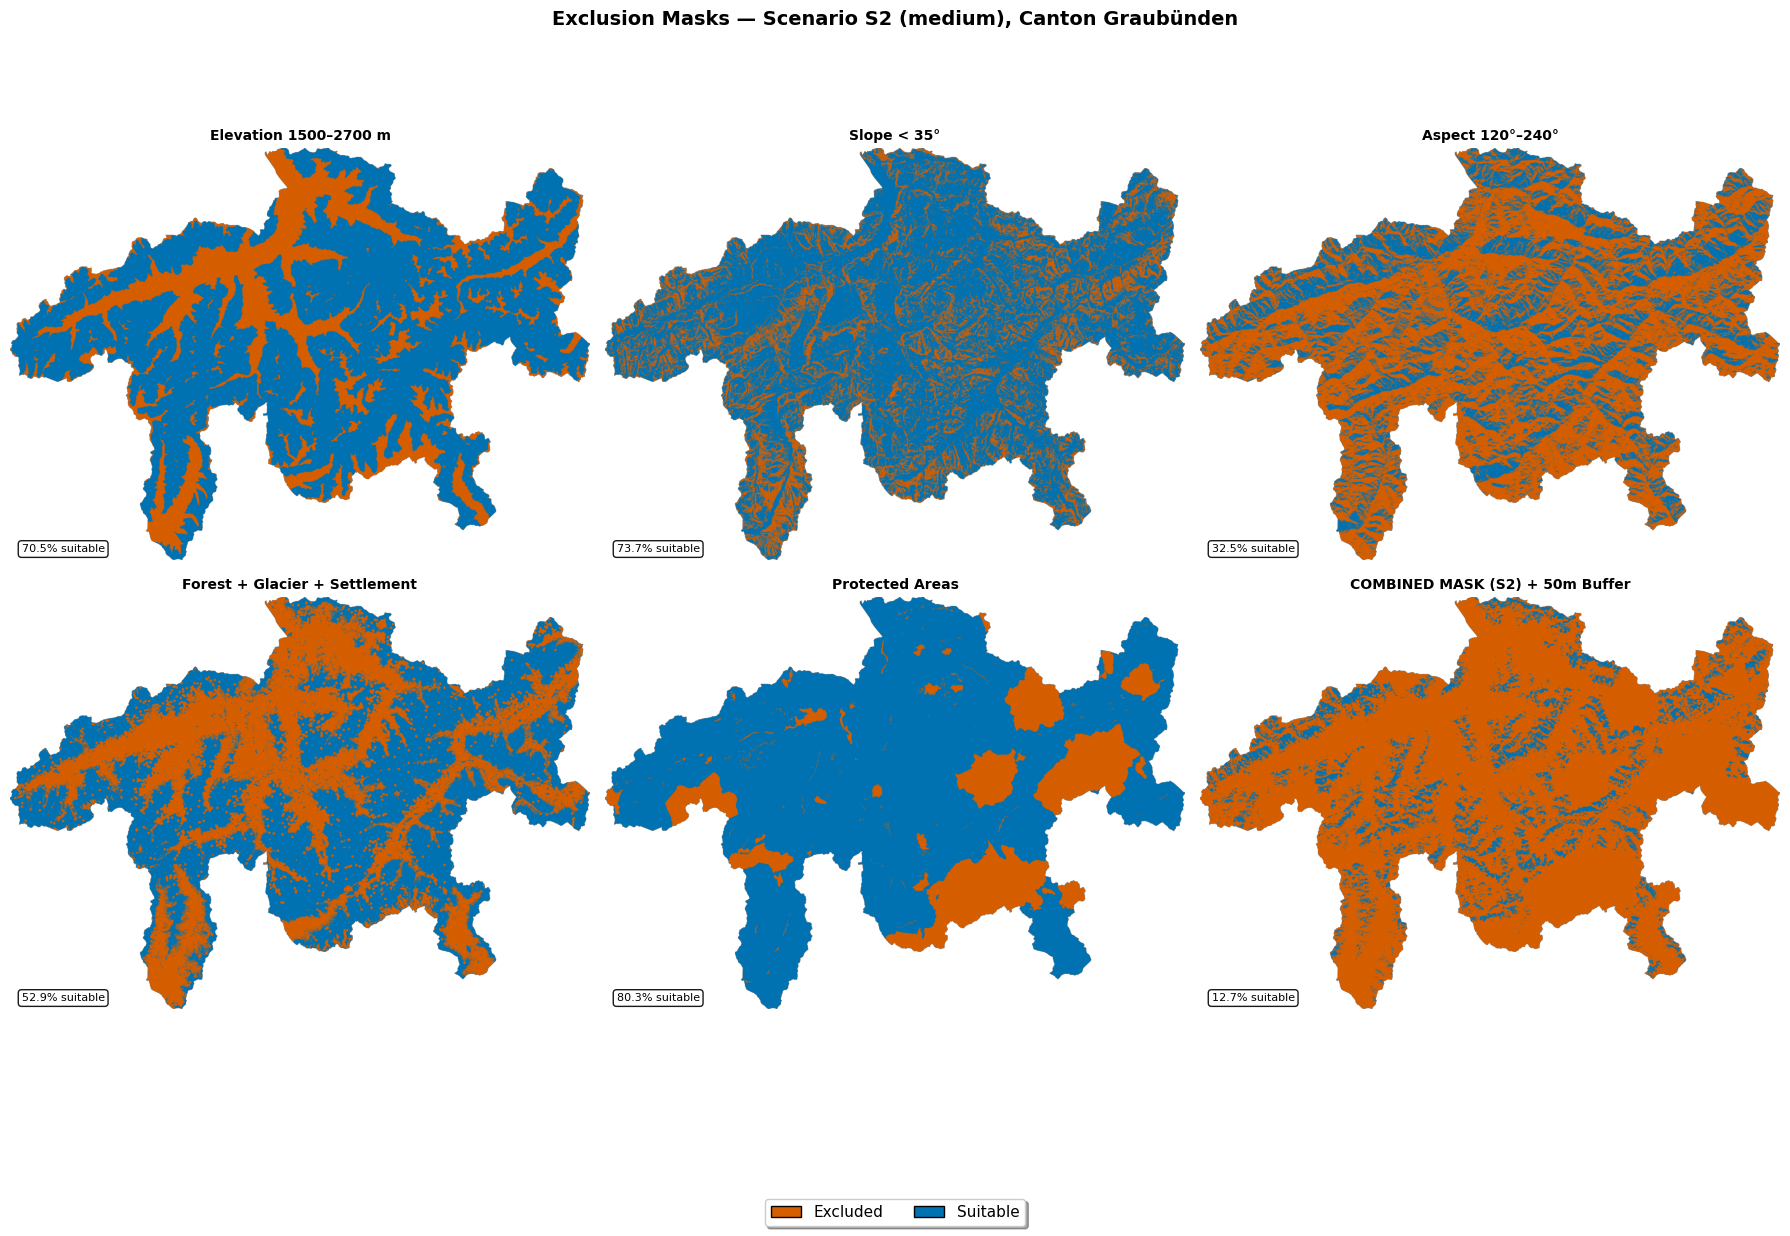

✓ Saved: ..\outputs\figures\constraint_masks.png


In [13]:
print("=== Visualization ===\n")

# --- Colorblind-friendly palette ---
cmap_rg = LinearSegmentedColormap.from_list("cb_safe", ["#D55E00", "#0072B2"], N=256)  # Orange (excluded) → Blue (suitable)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))  # Create 2×3 subplot grid
fig.suptitle("Exclusion Masks — Scenario S2 (medium), Canton Graubünden", fontsize=14, fontweight="bold")

# --- 6 example maps ---
plot_masks = [
    (c01_elev_min & c02_elev_max, "Elevation 1500–2700 m"),  # Combined elevation constraints
    (c03_slope, "Slope < 35°"),  # Slope constraint
    (c04_aspect, "Aspect 120°–240°"),  # North-facing constraint
    (c13_wald & c15_gletscher & c20_siedlung, "Forest + Glacier + Settlement"),  # Multiple land cover constraints
    (c06_moorlandschaften & c07_biotope & c09_bln & c10_nationalpark, "Protected Areas"),  # Conservation constraints
    (combined_buffered, "COMBINED MASK (S2) + 50m Buffer"),  # Final combined mask
]

for ax, (data, title) in zip(axes.flat, plot_masks):  # For each subplot
    masked = np.ma.masked_where(gr_mask_raster == 0, data.astype(float))   # Mask pixels outside GR
    ax.imshow(masked, cmap=cmap_rg, vmin=0, vmax=1, aspect="equal")       # Display with colorblind-safe colors
    ax.set_title(title, fontsize=10, fontweight="bold")  # Title
    ax.set_axis_off()  # Hide axes
    pct = data[gr_mask_raster == 1].sum() / total_px * 100                 # Percentage suitable
    ax.text(0.02, 0.02, f"{pct:.1f}% suitable", transform=ax.transAxes,  # Add text overlay
            fontsize=8, bbox=dict(boxstyle="round", fc="white", alpha=0.9))

# --- Legend ---
legend_elements = [
    Patch(facecolor="#D55E00", edgecolor="black", label="Excluded"),  # Orange = excluded
    Patch(facecolor="#0072B2", edgecolor="black", label="Suitable"),  # Blue = suitable
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2, fontsize=11,  # Add legend at bottom
           bbox_to_anchor=(0.5, -0.04), frameon=True, fancybox=True, shadow=True)

plt.tight_layout(rect=[0, 0.08, 1, 0.96])  # Adjust layout
out_dir = Path("../outputs/figures")  # Output directory
out_dir.mkdir(parents=True, exist_ok=True)  # Create if missing
fig.savefig(out_dir / "constraint_masks.png", dpi=150, bbox_inches="tight") # Save figure
plt.show()  # Display in notebook
print(f"✓ Saved: {out_dir / 'constraint_masks.png'}")

## Next Steps

The combined exclusion mask is located at:
```
data/processed/constraints/constraint_mask_s2.tif
```


- Pixel = 1: area is potentially suitable (all 20 criteria passed)
- Pixel = 0: area is excluded (at least 1 criterion violated)

**→ Continue with:** `03_preprocessing_wlc.ipynb` → Calculate suitability factors